## Installing light GBM 

In [1]:
!pip install lightgbm==3.3.5

In [2]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.metrics import mean_squared_error as mse
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')


In [3]:
# os.chdir("C:\Users\kkbha\Data")

## Genric Function That details all missing values (null Values)

In [4]:
def analyze_missing_values(df):
    """
    Analyze and display missing values in a DataFrame.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The input DataFrame to analyze for missing values
        
    Returns:
    --------
    pandas.DataFrame
        A DataFrame summarizing missing values by column
    """
    # Get count and percentage of missing values
    total_cells = np.prod(df.shape)
    total_missing = df.isnull().sum().sum()
    
    # Missing values by column
    missing_by_column = df.isnull().sum()
    missing_percentage_by_column = (df.isnull().sum() / len(df)) * 100
    
    # Create a summary DataFrame
    missing_summary = pd.DataFrame({
        'Missing Values': missing_by_column,
        'Percentage (%)': missing_percentage_by_column
    })
    
    # Sort by most missing
    missing_summary = missing_summary.sort_values('Missing Values', ascending=False)
    
    # Show only columns with missing values
    if missing_summary[missing_summary['Missing Values'] > 0].empty:
        print("No missing values found in the DataFrame.")
    else:
        print("Columns with missing values:")
        print(missing_summary[missing_summary['Missing Values'] > 0])
    
    # Overall summary
    print(f"\nTotal missing values: {total_missing} out of {total_cells} cells ({total_missing/total_cells:.2%})")
    
    return missing_summary

# Example usage:
# missing_data_summary = analyze_missing_values(MyData)

## Genric Function that replaces all missing numeric features with Median

In [5]:
def replace_nulls_with_median(df):
    """
    Replace null values in a DataFrame with the median of each column.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The input DataFrame with potential null values
        
    Returns:
    --------
    pandas.DataFrame
        A new DataFrame with null values replaced by column medians
    """
    # Create a copy of the DataFrame to avoid modifying the original
    df_clean = df.copy()
    
    # Get numeric columns only (median only works on numeric data)
    numeric_columns = df.select_dtypes(include=['number']).columns
    
    # Replace nulls with median for each numeric column
    for column in numeric_columns:
        if df[column].isnull().any():
            median_value = df[column].median()
            df_clean[column] = df[column].fillna(median_value)
            print(f"Replaced {df[column].isnull().sum()} null values in '{column}' with median: {median_value}")
    
    # Check if there are any remaining nulls in non-numeric columns
    remaining_nulls = df_clean.isnull().sum().sum()
    if remaining_nulls > 0:
        print(f"\nWarning: {remaining_nulls} null values remain in non-numeric columns.")
        print("This function only replaces nulls in numeric columns.")
    
    return df_clean

# Example usage:
# MyData = replace_nulls_with_median(MyData)

## Genric Function That displays all Unique Categorical values including Nulls.

In [6]:
import numpy as np

def display_categorical_uniques(df):
    """
    Displays distinct values for all categorical (object) columns.
    Replaces NaN with 'NULL' before displaying.
    """
    
    # Select categorical columns
    cat_cols = df.select_dtypes(include=['object']).columns

    # Loop through and print unique values
    for col in cat_cols:
        unique_vals = df[col].fillna("NULL").unique()
        unique_list = unique_vals.tolist()
        print(f"{col}: {unique_list}")


## Genric Function that replaces Non Numeric Categorical values with digital Numbers.

In [7]:
import pandas as pd
import numpy as np

def process_categorical(df):
    """
    Replaces NaN with 'Missing', prints unique values for each categorical column,
    and encodes those categorical columns directly in the given DataFrame.
    Missing is always encoded as 99.
    """
    
    # Select categorical (object) columns
    cat_cols = df.select_dtypes(include=['object']).columns
    
    # 1️⃣ Replace NaN with "Missing"
    for col in cat_cols:
        df[col] = df[col].fillna("Missing")
    
    # 2️⃣ Display distinct values
    print("===== DISTINCT VALUES FOR CATEGORICAL COLUMNS =====")
    for col in cat_cols:
        unique_list = df[col].unique().tolist()
        print(f"{col}: {unique_list}")
    
    # 3️⃣ Encode categorical columns
    for col in cat_cols:
        # Unique categories
        categories = df[col].unique().tolist()
        
        # Remove "Missing" so it can be given code 99
        if "Missing" in categories:
            categories.remove("Missing")
        
        # Assign numeric codes
        mapping = {cat: idx for idx, cat in enumerate(categories)}
        
        # Assign Missing → 99
        mapping["Missing"] = 99
        
        # Apply encoding
        df[col] = df[col].map(mapping)
    
    print("\nEncoding complete. Categorical columns updated in the original DataFrame.")


## Generic Encoding Function (Production-Ready)

In [8]:
def encode_categorical_features(df, categorical_cols):
    """
    Encodes categorical columns using pandas category codes
    suitable for LightGBM.

    Parameters:
    df : pd.DataFrame
        Input dataframe
    categorical_cols : list
        List of categorical column names

    Returns:
    encoded_df : pd.DataFrame
        DataFrame with encoded categorical columns
    """
    encoded_df = df.copy()

    for col in categorical_cols:
        encoded_df[col] = encoded_df[col].astype('category')
        encoded_df[col] = encoded_df[col].cat.codes

    return encoded_df


# VERY IMPORTANT: Train/Test Consistency
• If you encode train and test separately, category codes may mismatch.

In [9]:
def encode_categorical_train_test(train_df, test_df, categorical_cols):
    train_df = train_df.copy()
    test_df = test_df.copy()

    for col in categorical_cols:
        categories = train_df[col].astype('category').cat.categories
        
        train_df[col] = pd.Categorical(train_df[col], categories=categories).codes
        test_df[col] = pd.Categorical(test_df[col], categories=categories).codes

    return train_df, test_df
    #return  test_df


## Genric Function that displays all the Outliers Values.

In [10]:
import pandas as pd
import numpy as np

def display_outlier_percentiles(df, features, lower_q=0.10, upper_q=0.90):
    """
    Displays the lower_q and upper_q percentiles for selected features.
    Does NOT replace values — only reports outlier boundaries.

    Parameters:
        df (DataFrame): The input DataFrame
        features (list): List of numeric features
        lower_q (float): Lower percentile (default 0.10)
        upper_q (float): Upper percentile (default 0.90)
    """

    # Calculate percentiles for all features at once
    percentiles = df[features].quantile([lower_q, upper_q])
    
    # Display summary table
    print(f"{int(lower_q*100)}th and {int(upper_q*100)}th Percentiles for Selected Features:")
    print(percentiles)

    # Detailed per-feature output
    print("\nDetailed Percentile Information:")
    for feature in features:
        p_low = df[feature].quantile(lower_q)
        p_high = df[feature].quantile(upper_q)

        print(f"{feature}:")
        print(f"  {int(lower_q*100)}th percentile: {p_low:,.2f}")
        print(f"  {int(upper_q*100)}th percentile: {p_high:,.2f}")
        print(f"  Range between percentiles: {(p_high - p_low):,.2f}")
        print()


## Genric Function that replaces all the outliers with approriate percentile Values.

In [11]:
import pandas as pd
import numpy as np

def handle_outliers(df, features, lower_q=0.10, upper_q=0.90):
    """
    Handles outliers for specified numeric features.
    
    Parameters:
        df (DataFrame): Input DataFrame
        features (list): List of numeric column names
        lower_q (float): Lower quantile for IQR calculation (default 0.10)
        upper_q (float): Upper quantile for IQR calculation (default 0.90)
    """
    
    for feature in features:
        col_df = pd.DataFrame(df[feature])
        
        # Q1, Q3 and IQR
        Q1  = col_df.quantile(q=lower_q)
        Q3  = col_df.quantile(q=upper_q)
        IQR = Q3 - Q1
        
        # Bounds
        IQR_LL = int(Q1.iloc[0] - 1.5 * IQR.iloc[0])
        IQR_UL = int(Q3.iloc[0] + 1.5 * IQR.iloc[0])

        # Replace outliers:
        # High outliers → 99th percentile
        df.loc[df[feature] > IQR_UL, feature] = int(col_df.quantile(q=0.99).iloc[0])
        
        # Low outliers → 1st percentile
        df.loc[df[feature] < IQR_LL, feature] = int(col_df.quantile(q=0.01).iloc[0])
        
        print(f"Outliers handled for feature: {feature}")


In [12]:
MyData = pd.read_csv(r"..\..\data\kaggle_HouspriceAdvancedregresiontrain.csv")
MyData.shape


(1460, 81)

In [13]:
MyData.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [14]:
analyze_missing_values(MyData)

Columns with missing values:
              Missing Values  Percentage (%)
PoolQC                  1453       99.520548
MiscFeature             1406       96.301370
Alley                   1369       93.767123
Fence                   1179       80.753425
MasVnrType               872       59.726027
FireplaceQu              690       47.260274
LotFrontage              259       17.739726
GarageQual                81        5.547945
GarageFinish              81        5.547945
GarageType                81        5.547945
GarageYrBlt               81        5.547945
GarageCond                81        5.547945
BsmtFinType2              38        2.602740
BsmtExposure              38        2.602740
BsmtCond                  37        2.534247
BsmtQual                  37        2.534247
BsmtFinType1              37        2.534247
MasVnrArea                 8        0.547945
Electrical                 1        0.068493

Total missing values: 7829 out of 118260 cells (6.62%)


,Missing Values,Percentage (%)
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
...,...,...
MoSold,0,0.000000
YrSold,0,0.000000
SaleType,0,0.000000
SaleCondition,0,0.000000


In [15]:
MyData = replace_nulls_with_median(MyData)

Replaced 259 null values in 'LotFrontage' with median: 69.0
Replaced 8 null values in 'MasVnrArea' with median: 0.0
Replaced 81 null values in 'GarageYrBlt' with median: 1980.0

This function only replaces nulls in numeric columns.


In [16]:
MyData.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [17]:
display_categorical_uniques(MyData)

MSZoning: ['RL', 'RM', 'C (all)', 'FV', 'RH']
Street: ['Pave', 'Grvl']
Alley: ['NULL', 'Grvl', 'Pave']
LotShape: ['Reg', 'IR1', 'IR2', 'IR3']
LandContour: ['Lvl', 'Bnk', 'Low', 'HLS']
Utilities: ['AllPub', 'NoSeWa']
LotConfig: ['Inside', 'FR2', 'Corner', 'CulDSac', 'FR3']
LandSlope: ['Gtl', 'Mod', 'Sev']
Neighborhood: ['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst', 'NWAmes', 'OldTown', 'BrkSide', 'Sawyer', 'NridgHt', 'NAmes', 'SawyerW', 'IDOTRR', 'MeadowV', 'Edwards', 'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill', 'Blmngtn', 'BrDale', 'SWISU', 'Blueste']
Condition1: ['Norm', 'Feedr', 'PosN', 'Artery', 'RRAe', 'RRNn', 'RRAn', 'PosA', 'RRNe']
Condition2: ['Norm', 'Artery', 'RRNn', 'Feedr', 'PosN', 'PosA', 'RRAn', 'RRAe']
BldgType: ['1Fam', '2fmCon', 'Duplex', 'TwnhsE', 'Twnhs']
HouseStyle: ['2Story', '1Story', '1.5Fin', '1.5Unf', 'SFoyer', 'SLvl', '2.5Unf', '2.5Fin']
RoofStyle: ['Gable', 'Hip', 'Gambrel', 'Mansard', 'Flat', 'Shed']
RoofMatl: ['CompShg', 'WdShngl

In [18]:
categorical_cols = [
    'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 
    'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 
    'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 
    'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 
    'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 
    'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 
    'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 
    'SaleType', 'SaleCondition'
]

# Print the list to verify
print(f"Total categorical columns: {len(categorical_cols)}")
print(categorical_cols)
train_df = MyData

Total categorical columns: 43
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


In [19]:
MyData = encode_categorical_features(MyData, categorical_cols)
#process_categorical(MyData)
MyData.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.0,8450,1,-1,3,3,0,...,0,-1,-1,-1,0,2,2008,8,4,208500
1,2,20,3,80.0,9600,1,-1,3,3,0,...,0,-1,-1,-1,0,5,2007,8,4,181500
2,3,60,3,68.0,11250,1,-1,0,3,0,...,0,-1,-1,-1,0,9,2008,8,4,223500
3,4,70,3,60.0,9550,1,-1,0,3,0,...,0,-1,-1,-1,0,2,2006,8,0,140000
4,5,60,3,84.0,14260,1,-1,0,3,0,...,0,-1,-1,-1,0,12,2008,8,4,250000


In [20]:
analyze_missing_values(MyData)

No missing values found in the DataFrame.

Total missing values: 0 out of 118260 cells (0.00%)


,Missing Values,Percentage (%)
Id,0,0.0
MSSubClass,0,0.0
MSZoning,0,0.0
LotFrontage,0,0.0
LotArea,0,0.0
...,...,...
MoSold,0,0.0
YrSold,0,0.0
SaleType,0,0.0
SaleCondition,0,0.0


In [21]:
features = ['LotFrontage','LotArea','MiscVal','SalePrice']
display_outlier_percentiles(MyData, features)


10th and 90th Percentiles for Selected Features:
     LotFrontage  LotArea  MiscVal  SalePrice
0.1         49.0   5000.0      0.0   106475.0
0.9         92.0  14381.7      0.0   278000.0

Detailed Percentile Information:
LotFrontage:
  10th percentile: 49.00
  90th percentile: 92.00
  Range between percentiles: 43.00

LotArea:
  10th percentile: 5,000.00
  90th percentile: 14,381.70
  Range between percentiles: 9,381.70

MiscVal:
  10th percentile: 0.00
  90th percentile: 0.00
  Range between percentiles: 0.00

SalePrice:
  10th percentile: 106,475.00
  90th percentile: 278,000.00
  Range between percentiles: 171,525.00



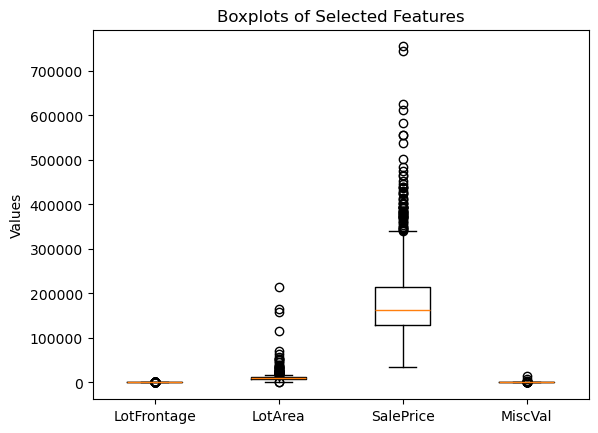

In [22]:
import matplotlib.pyplot as plt

features = ['LotFrontage','LotArea','SalePrice','MiscVal']

plt.boxplot([MyData[f] for f in features], labels=features)
plt.title("Boxplots of Selected Features")
plt.ylabel("Values")
plt.show()


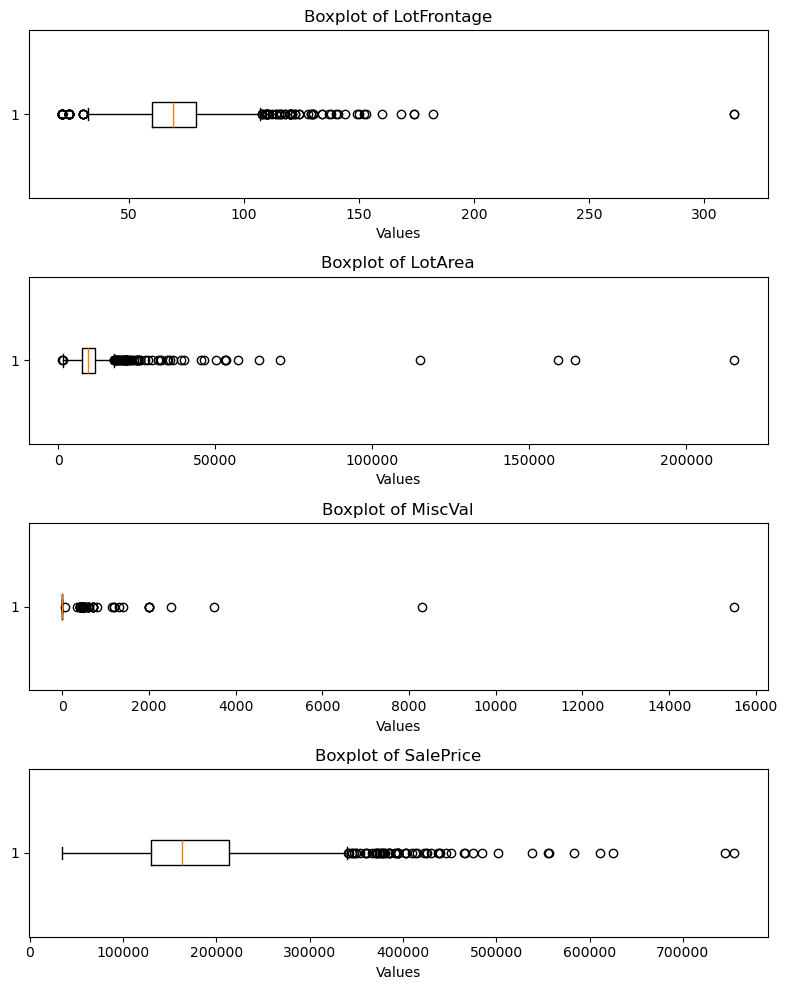

In [23]:
import matplotlib.pyplot as plt

features = ['LotFrontage','LotArea','MiscVal', 'SalePrice']

plt.figure(figsize=(8, 10))  # adjust size as needed

for i, feature in enumerate(features, 1):
    plt.subplot(len(features), 1, i)  # one plot per row
    plt.boxplot(MyData[feature], vert=False)
    plt.title(f"Boxplot of {feature}")
    plt.xlabel("Values")

plt.tight_layout()  # avoids overlap
plt.show()


In [24]:
features1 = ['LotFrontage','LotArea','MiscVal']
handle_outliers(MyData,features1)

Outliers handled for feature: LotFrontage
Outliers handled for feature: LotArea
Outliers handled for feature: MiscVal


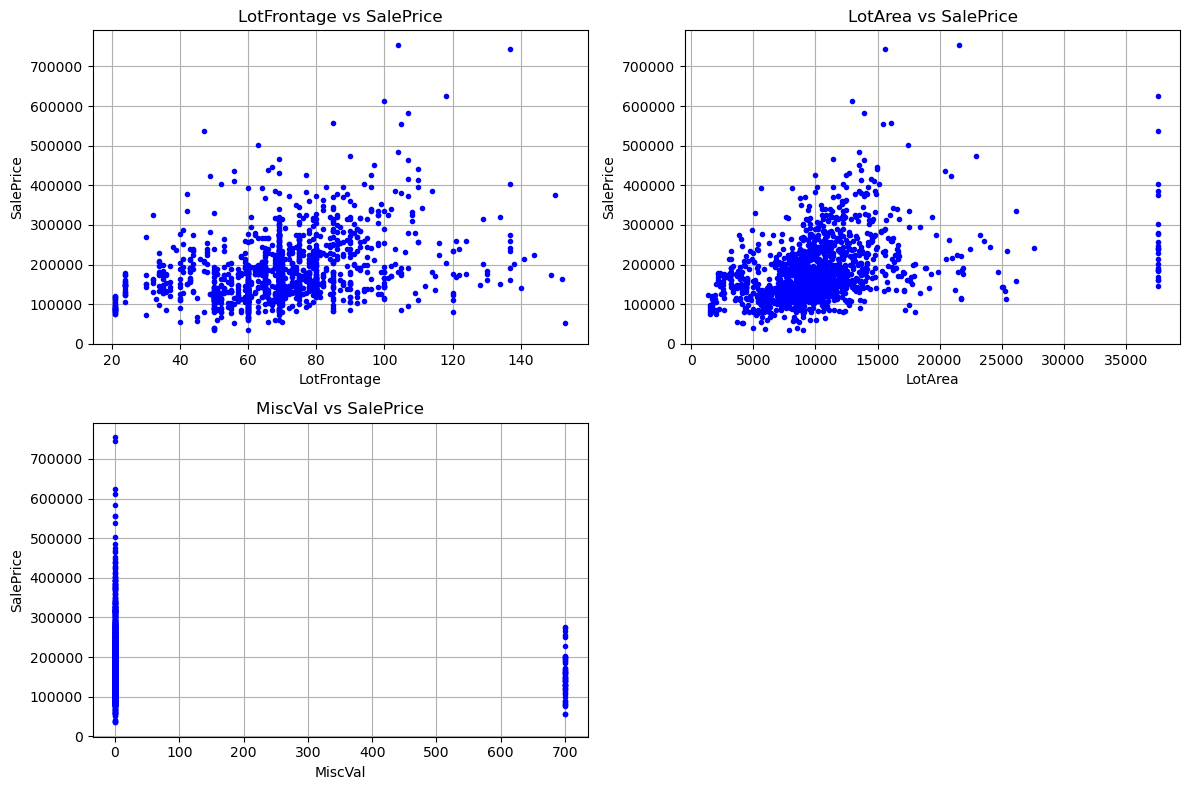

In [25]:
# Load your CSV
#df_corr = pd.read_csv(r'..\data\CCPP_data.csv')

# Define features and target
features1 = ['LotFrontage','LotArea', 'MiscVal']
target = 'SalePrice'

# Create subplots: 2 rows × 2 columns
plt.figure(figsize=(12, 8))

for i, feature in enumerate(features1):
    plt.subplot(2, 2, i + 1)
    plt.plot(MyData[feature], MyData[target], 'bo', markersize=3)  # blue dots
    plt.title(f'{feature} vs {target}')
    plt.xlabel(feature)
    plt.ylabel(target)
    plt.grid(True)

plt.tight_layout()
plt.show()


<h2>Correlation Matrix</h2>



In [26]:
#Check Correleation Matrix to check the strength of Variation between 2 Variables
%matplotlib inline
correlation_matrix = MyData.corr().round(2)
f, ax = plt.subplots(figsize= (10,5))
sns.heatmap(data=correlation_matrix,annot=True) 

<Axes: >

In [27]:
correlation_matrix.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,1.00,0.01,-0.01,-0.02,-0.01,0.01,-0.00,0.03,-0.02,0.01,...,0.06,0.07,-0.01,-0.04,-0.04,0.02,0.00,0.02,-0.01,-0.02
MSSubClass,0.01,1.00,0.04,-0.39,-0.28,-0.02,0.18,0.12,-0.00,-0.02,...,0.01,0.01,-0.11,-0.05,-0.04,-0.01,-0.02,0.01,-0.02,-0.08
MSZoning,-0.01,0.04,1.00,-0.12,-0.06,0.09,-0.19,0.06,-0.02,-0.00,...,-0.00,-0.00,0.07,-0.00,-0.00,-0.03,-0.02,0.10,0.01,-0.17
LotFrontage,-0.02,-0.39,-0.12,1.00,0.46,-0.04,-0.20,-0.15,-0.04,-0.00,...,0.10,0.09,0.03,0.01,0.01,0.01,0.01,-0.03,0.06,0.36
LotArea,-0.01,-0.28,-0.06,0.46,1.00,-0.13,-0.14,-0.26,-0.15,0.02,...,0.11,0.12,-0.06,0.05,0.05,-0.01,-0.03,0.00,0.04,0.38
Street,0.01,-0.02,0.09,-0.04,-0.13,1.00,0.02,-0.01,0.12,0.00,...,0.00,0.00,0.03,-0.16,-0.16,0.00,-0.03,0.01,0.01,0.04
Alley,-0.00,0.18,-0.19,-0.20,-0.14,0.02,1.00,0.10,-0.08,-0.01,...,-0.02,-0.02,-0.02,-0.01,-0.01,-0.02,-0.01,-0.01,-0.04,-0.09
LotShape,0.03,0.12,0.06,-0.15,-0.26,-0.01,0.10,1.00,0.09,-0.04,...,-0.02,-0.02,0.05,-0.01,-0.02,-0.03,0.04,-0.00,-0.04,-0.26
LandContour,-0.02,-0.00,-0.02,-0.04,-0.15,0.12,-0.08,0.09,1.00,0.01,...,-0.01,-0.03,0.03,0.01,0.01,-0.01,0.02,-0.03,0.03,0.02
Utilities,0.01,-0.02,-0.00,-0.00,0.02,0.00,-0.01,-0.04,0.01,1.00,...,-0.00,-0.00,-0.01,-0.01,-0.01,-0.05,0.02,-0.13,-0.09,-0.01


## Code sample/template from GeeksforGeeks.org

In [28]:
#features = df.drop('charges', axis=1)
#target = df['charges']

#X_train, X_val, Y_train, Y_val = train_test_split(
#    features, target, test_size=0.25, random_state=2023
#)

#scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_val = scaler.transform(X_val)

In [29]:
from sklearn.model_selection import train_test_split
import numpy as np

# --- Split training data ---
X_train, X_valid, y_train, y_valid = train_test_split(
    MyData.drop(columns=['MoSold','YrSold','SalePrice']), 
    np.log1p(MyData['SalePrice']),   # LOG TRANSFORM TARGET
    test_size=0.2,
    random_state=42
)
X_train_fit = X_train.drop(columns=['Id'])
X_valid_fit = X_valid.drop(columns=['Id'])

# --- Fit scaler ONLY on training data ---
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_fit)
X_valid_scaled = scaler_X.transform(X_valid_fit)



In [30]:
# Filter categorical_cols to only include columns present in X_train
categorical_cols_present = [col for col in categorical_cols if col in X_train.columns]
categorical_indices = [X_train.columns.get_loc(col) for col in categorical_cols_present]
model = lgb.LGBMRegressor(
    objective = 'regression',
    metric   = 'rmse',
    max_cat_threshold=32,
    min_data_per_group=50,
    num_round = 125,
    #early_stopping_rounds=10,
    random_state=42
)
model.fit(
    X_train_scaled, 
    y_train,
    categorical_feature=categorical_indices
)

[LightGBM] [Warning] num_iterations is set=125, num_round=125 will be ignored. Current value: num_iterations=125


LGBMRegressor(max_cat_threshold=32, metric='rmse', min_data_per_group=50,
              num_round=125, objective='regression', random_state=42)

## MAE and RMSE for Training Data

In [31]:
y_train_log     = model.predict(X_train_scaled)
y_train_pred_actual  = np.expm1(y_train_log)
y_train_actual =  np.expm1(y_train)

mae = mean_absolute_error(y_train_pred_actual, y_train_actual)
print(f"MAE: {mae:.3f}")
print("Training RMSE: ", np.sqrt(mse(y_train_pred_actual, y_train_actual)))


MAE: 4783.396
Training RMSE:  9109.3454447959


## Comparing the Actual to Predicted Value in Train Environment

In [32]:
# Compare actual vs predicted
comparison_train = pd.DataFrame({
    'Actual': y_train_actual.values.flatten() if hasattr(y_train_actual, 'values') else y_train_actual,  # Convert to numpy if it's a Series
    'Predicted': y_train_pred_actual.values.flatten() if hasattr(y_train_pred_actual, 'values') else y_train_pred_actual  # Convert to numpy if it's a Series
})

print(comparison_train)

        Actual      Predicted
0     145000.0  146725.256370
1     178000.0  175675.732319
2      85000.0   86842.811611
3     175000.0  167266.993925
4     127000.0  129221.683914
...        ...            ...
1163  176432.0  181302.085316
1164  135000.0  135886.097376
1165  115000.0  118584.387058
1166  189950.0  180678.555755
1167  174000.0  184112.566311

[1168 rows x 2 columns]


In [33]:
# Compare actual vs predicted
comparison_train = pd.DataFrame({
    'Actual': y_train_actual.values.flatten(),
    'Predicted': y_train_pred_actual.flatten()
})

# Calculate percentage difference
comparison_train['Percent_Diff'] = abs(comparison_train['Actual'] - comparison_train['Predicted']) / comparison_train['Actual'] * 100

# Count predictions in different variance ranges
count_under_10 = len(comparison_train[comparison_train['Percent_Diff'] <= 10])
count_10_to_50 = len(comparison_train[(comparison_train['Percent_Diff'] > 10) & (comparison_train['Percent_Diff'] <= 50)])
count_over_50 = len(comparison_train[comparison_train['Percent_Diff'] > 50])

# Display the comparison dataframe
print(comparison_train)

# Display the counts
print("\nPrediction Variance Counts:")
print(f"Predictions varying ≤ 10%: {count_under_10}")
print(f"Predictions varying > 10% and ≤ 50%: {count_10_to_50}")
print(f"Predictions varying > 50%: {count_over_50}")

# Optional: Display as percentages of total
total = len(comparison_train)
print("\nAs percentages:")
print(f"Predictions varying ≤ 10%: {count_under_10/total*100:.1f}%")
print(f"Predictions varying > 10% and ≤ 50%: {count_10_to_50/total*100:.1f}%")
print(f"Predictions varying > 50%: {count_over_50/total*100:.1f}%")

        Actual      Predicted  Percent_Diff
0     145000.0  146725.256370      1.189832
1     178000.0  175675.732319      1.305768
2      85000.0   86842.811611      2.168014
3     175000.0  167266.993925      4.418861
4     127000.0  129221.683914      1.749357
...        ...            ...           ...
1163  176432.0  181302.085316      2.760319
1164  135000.0  135886.097376      0.656368
1165  115000.0  118584.387058      3.116858
1166  189950.0  180678.555755      4.880992
1167  174000.0  184112.566311      5.811820

[1168 rows x 3 columns]

Prediction Variance Counts:
Predictions varying ≤ 10%: 1144
Predictions varying > 10% and ≤ 50%: 23
Predictions varying > 50%: 1

As percentages:
Predictions varying ≤ 10%: 97.9%
Predictions varying > 10% and ≤ 50%: 2.0%
Predictions varying > 50%: 0.1%


## MAE and RMSE for Validation Data

In [34]:
y_pred_log     = model.predict(X_valid_scaled)
y_pred_actual  = np.expm1(y_pred_log)
y_valid_actual =  np.expm1(y_valid)

mae = mean_absolute_error(y_valid_actual, y_pred_actual)
print(f"MAE: {mae:.3f}")
print("Validation RMSE: ", np.sqrt(mse(y_valid_actual, y_pred_actual)))


MAE: 17103.397
Validation RMSE:  28608.63594738895


## Comparing the Actual to Predicted Value in Validation Environment

In [35]:
# Compare actual vs predicted
comparison = pd.DataFrame({
    'Actual': y_valid_actual.values.flatten(),
    'Predicted': y_pred_actual.flatten()
})

print(comparison)


       Actual      Predicted
0    154500.0  143613.819844
1    325000.0  332391.085432
2    115000.0  131107.209981
3    159000.0  160527.109346
4    315500.0  323331.616888
..        ...            ...
287   89471.0  110111.542815
288  260000.0  228852.921642
289  189000.0  189498.970682
290  108000.0  122074.901031
291  124500.0  110703.645061

[292 rows x 2 columns]


## Code to display values that vary <= 10%,> 10% and <= 50% and > 50%

In [36]:
# Compare actual vs predicted
comparison = pd.DataFrame({
    'Actual': y_valid_actual.values.flatten(),
    'Predicted': y_pred_actual.flatten()
})

# Calculate percentage difference
comparison['Percent_Diff'] = abs(comparison['Actual'] - comparison['Predicted']) / comparison['Actual'] * 100

# Count predictions in different variance ranges
count_under_10 = len(comparison[comparison['Percent_Diff'] <= 10])
count_10_to_50 = len(comparison[(comparison['Percent_Diff'] > 10) & (comparison['Percent_Diff'] <= 50)])
count_over_50 = len(comparison[comparison['Percent_Diff'] > 50])

# Display the comparison dataframe
print(comparison)

# Display the counts
print("\nPrediction Variance Counts:")
print(f"Predictions varying ≤ 10%: {count_under_10}")
print(f"Predictions varying > 10% and ≤ 50%: {count_10_to_50}")
print(f"Predictions varying > 50%: {count_over_50}")

# Optional: Display as percentages of total
total = len(comparison)
print("\nAs percentages:")
print(f"Predictions varying ≤ 10%: {count_under_10/total*100:.1f}%")
print(f"Predictions varying > 10% and ≤ 50%: {count_10_to_50/total*100:.1f}%")
print(f"Predictions varying > 50%: {count_over_50/total*100:.1f}%")

       Actual      Predicted  Percent_Diff
0    154500.0  143613.819844      7.046071
1    325000.0  332391.085432      2.274180
2    115000.0  131107.209981     14.006270
3    159000.0  160527.109346      0.960446
4    315500.0  323331.616888      2.482287
..        ...            ...           ...
287   89471.0  110111.542815     23.069534
288  260000.0  228852.921642     11.979646
289  189000.0  189498.970682      0.264006
290  108000.0  122074.901031     13.032316
291  124500.0  110703.645061     11.081410

[292 rows x 3 columns]

Prediction Variance Counts:
Predictions varying ≤ 10%: 194
Predictions varying > 10% and ≤ 50%: 91
Predictions varying > 50%: 7

As percentages:
Predictions varying ≤ 10%: 66.4%
Predictions varying > 10% and ≤ 50%: 31.2%
Predictions varying > 50%: 2.4%


## Comparison of Orginal and Predicted values 

In [37]:
MyData_test = pd.read_csv(r"..\..\data\kaggle_HouspriceAdvancedregresiontest.csv")
MyData_test.shape

(1459, 80)

In [38]:
MyData_test.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [39]:
analyze_missing_values(MyData_test)

Columns with missing values:
              Missing Values  Percentage (%)
PoolQC                  1456       99.794380
MiscFeature             1408       96.504455
Alley                   1352       92.666210
Fence                   1169       80.123372
MasVnrType               894       61.274846
FireplaceQu              730       50.034270
LotFrontage              227       15.558602
GarageYrBlt               78        5.346127
GarageCond                78        5.346127
GarageFinish              78        5.346127
GarageQual                78        5.346127
GarageType                76        5.209047
BsmtCond                  45        3.084304
BsmtQual                  44        3.015764
BsmtExposure              44        3.015764
BsmtFinType1              42        2.878684
BsmtFinType2              42        2.878684
MasVnrArea                15        1.028101
MSZoning                   4        0.274160
BsmtHalfBath               2        0.137080
Utilities                 

,Missing Values,Percentage (%)
PoolQC,1456,99.794380
MiscFeature,1408,96.504455
Alley,1352,92.666210
Fence,1169,80.123372
MasVnrType,894,61.274846
...,...,...
EnclosedPorch,0,0.000000
MiscVal,0,0.000000
MoSold,0,0.000000
YrSold,0,0.000000


In [40]:
MyData_test = replace_nulls_with_median(MyData_test)
MyData_test.head(5)

Replaced 227 null values in 'LotFrontage' with median: 67.0
Replaced 15 null values in 'MasVnrArea' with median: 0.0
Replaced 1 null values in 'BsmtFinSF1' with median: 350.5
Replaced 1 null values in 'BsmtFinSF2' with median: 0.0
Replaced 1 null values in 'BsmtUnfSF' with median: 460.0
Replaced 1 null values in 'TotalBsmtSF' with median: 988.0
Replaced 2 null values in 'BsmtFullBath' with median: 0.0
Replaced 2 null values in 'BsmtHalfBath' with median: 0.0
Replaced 78 null values in 'GarageYrBlt' with median: 1979.0
Replaced 1 null values in 'GarageCars' with median: 2.0
Replaced 1 null values in 'GarageArea' with median: 480.0

This function only replaces nulls in numeric columns.


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [41]:
display_categorical_uniques(MyData_test)

MSZoning: ['RH', 'RL', 'RM', 'FV', 'C (all)', 'NULL']
Street: ['Pave', 'Grvl']
Alley: ['NULL', 'Pave', 'Grvl']
LotShape: ['Reg', 'IR1', 'IR2', 'IR3']
LandContour: ['Lvl', 'HLS', 'Bnk', 'Low']
Utilities: ['AllPub', 'NULL']
LotConfig: ['Inside', 'Corner', 'FR2', 'CulDSac', 'FR3']
LandSlope: ['Gtl', 'Mod', 'Sev']
Neighborhood: ['NAmes', 'Gilbert', 'StoneBr', 'BrDale', 'NPkVill', 'NridgHt', 'Blmngtn', 'NoRidge', 'Somerst', 'SawyerW', 'Sawyer', 'NWAmes', 'OldTown', 'BrkSide', 'ClearCr', 'SWISU', 'Edwards', 'CollgCr', 'Crawfor', 'Blueste', 'IDOTRR', 'Mitchel', 'Timber', 'MeadowV', 'Veenker']
Condition1: ['Feedr', 'Norm', 'PosN', 'RRNe', 'Artery', 'RRNn', 'PosA', 'RRAn', 'RRAe']
Condition2: ['Norm', 'Feedr', 'PosA', 'PosN', 'Artery']
BldgType: ['1Fam', 'TwnhsE', 'Twnhs', 'Duplex', '2fmCon']
HouseStyle: ['1Story', '2Story', 'SLvl', '1.5Fin', 'SFoyer', '2.5Unf', '1.5Unf']
RoofStyle: ['Gable', 'Hip', 'Gambrel', 'Flat', 'Mansard', 'Shed']
RoofMatl: ['CompShg', 'Tar&Grv', 'WdShake', 'WdShngl']
Ext

In [42]:
#process_categorical(MyData_test)
MyData_test=encode_categorical_features(MyData_test, categorical_cols)
# Use the encoded test data for display
MyData_test.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,2,80.0,11622,1,-1,3,3,0,...,120,0,-1,2,-1,0,6,2010,8,4
1,1462,20,3,81.0,14267,1,-1,0,3,0,...,0,0,-1,-1,0,12500,6,2010,8,4
2,1463,60,3,74.0,13830,1,-1,0,3,0,...,0,0,-1,2,-1,0,3,2010,8,4
3,1464,60,3,78.0,9978,1,-1,0,3,0,...,0,0,-1,-1,-1,0,6,2010,8,4
4,1465,120,3,43.0,5005,1,-1,0,1,0,...,144,0,-1,-1,-1,0,1,2010,8,4


In [43]:
test_features = ['LotFrontage','LotArea','MiscVal']
display_outlier_percentiles(MyData_test, test_features)

10th and 90th Percentiles for Selected Features:
     LotFrontage  LotArea  MiscVal
0.1         45.0   4793.0      0.0
0.9         91.0  14259.0      0.0

Detailed Percentile Information:
LotFrontage:
  10th percentile: 45.00
  90th percentile: 91.00
  Range between percentiles: 46.00

LotArea:
  10th percentile: 4,793.00
  90th percentile: 14,259.00
  Range between percentiles: 9,466.00

MiscVal:
  10th percentile: 0.00
  90th percentile: 0.00
  Range between percentiles: 0.00



In [44]:
test_features = ['LotFrontage','LotArea','MiscVal']
handle_outliers(MyData,test_features)

Outliers handled for feature: LotFrontage
Outliers handled for feature: LotArea
Outliers handled for feature: MiscVal


In [45]:
#Check Correleation Matrix to check the strength of Variation between 2 Variables
%matplotlib inline
test_correlation_matrix = MyData_test.corr().round(2)
f, ax = plt.subplots(figsize= (10,5))
sns.heatmap(data=correlation_matrix,annot=True)

<Axes: >

In [46]:
test_correlation_matrix .head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,1.00,0.00,0.05,0.01,0.05,0.00,-0.02,0.01,-0.03,0.02,...,0.03,0.05,0.03,0.01,-0.02,-0.01,0.14,-0.97,-0.03,0.01
MSSubClass,0.00,1.00,0.03,-0.42,-0.36,0.03,0.18,0.06,-0.01,0.03,...,-0.07,-0.02,-0.01,-0.11,-0.03,-0.05,0.01,-0.01,0.05,-0.02
MSZoning,0.05,0.03,1.00,-0.12,-0.11,0.18,-0.16,0.12,-0.04,0.10,...,0.01,-0.00,-0.00,0.13,0.01,0.01,-0.02,-0.02,0.02,-0.04
LotFrontage,0.01,-0.42,-0.12,1.00,0.53,-0.06,-0.20,-0.11,-0.01,-0.04,...,0.10,0.13,0.05,-0.02,0.03,0.07,0.01,-0.02,-0.03,0.00
LotArea,0.05,-0.36,-0.11,0.53,1.00,-0.03,-0.16,-0.25,-0.08,-0.12,...,0.09,0.14,0.04,-0.03,0.07,0.14,0.01,-0.05,-0.02,-0.01
Street,0.00,0.03,0.18,-0.06,-0.03,1.00,0.02,-0.02,0.07,0.29,...,0.02,0.00,0.00,-0.00,0.01,0.01,0.03,-0.01,0.01,0.03
Alley,-0.02,0.18,-0.16,-0.20,-0.16,0.02,1.00,0.07,0.02,0.01,...,0.00,-0.02,-0.01,-0.04,-0.00,-0.00,-0.03,0.01,-0.08,-0.05
LotShape,0.01,0.06,0.12,-0.11,-0.25,-0.02,0.07,1.00,0.10,0.01,...,-0.02,-0.01,-0.04,0.07,0.01,-0.06,0.05,0.02,-0.03,-0.11
LandContour,-0.03,-0.01,-0.04,-0.01,-0.08,0.07,0.02,0.10,1.00,0.07,...,-0.06,-0.03,-0.08,0.01,-0.00,-0.07,0.01,-0.00,-0.03,0.04
Utilities,0.02,0.03,0.10,-0.04,-0.12,0.29,0.01,0.01,0.07,1.00,...,0.01,0.00,0.00,0.02,-0.10,-0.02,0.03,-0.02,0.04,-0.01


In [47]:
X_test_fit = MyData_test.drop(columns=['Id','MoSold','YrSold'])
X_test_scaled = scaler_X.transform(X_test_fit)

y_test_log = model.predict(X_test_scaled)
y_test_actual = np.expm1(y_test_log)  # Convert back from log scale


In [48]:
len(y_test_actual) == 1459

True

In [49]:
# 1. Check raw model predictions BEFORE expm1
print("Min prediction (log space):", y_test_log.min())
print("Max prediction (log space):", y_test_log.max())

# 2. Show a few negative predictions
negatives = y_test_actual[y_test_actual < 0]
print("Number of negative predictions:", len(negatives))
print("First 10 negative predictions:", negatives[:10])


Min prediction (log space): 10.832580110606658
Max prediction (log space): 13.131991044146098
Number of negative predictions: 0
First 10 negative predictions: []


In [50]:
df_submission = pd.DataFrame({
    'Id': MyData_test['Id'],
    'SalePrice': y_test_actual
})

print(df_submission.head())




     Id      SalePrice
0  1461  126511.440526
1  1462  159587.343869
2  1463  185529.254305
3  1464  185115.012462
4  1465  191876.578082


In [51]:
df_submission.to_csv(r'..\..\results\submission_housprices.csv', index=False)
print("CSV file has been created successfully!")

CSV file has been created successfully!


In [52]:
df_submission['SalePrice'] < 0

0       False
1       False
2       False
3       False
4       False
        ...  
1454    False
1455    False
1456    False
1457    False
1458    False
Name: SalePrice, Length: 1459, dtype: bool

In [53]:
filtered_df = df_submission[df_submission['SalePrice'] < 0]
print(filtered_df)

Empty DataFrame
Columns: [Id, SalePrice]
Index: []
